# FAI Capstone — Experiment 1: Convergence Condition Validation
  Environment: Custom 4×4 GridWorld

# What we test:
   Exploration  -> epsilon-greedy (ε=0.1) vs greedy (ε=0)
   LR schedule  -> constant α | 1/n (Robbins-Monro) | 1/n² (violates RM)

 Both Q-learning and SARSA are run under all 6 combinations.
 30 seeds per condition. RMSE vs Q* tracked every episode.

This code cell uses the !pip install command to install three Python libraries: gymnasium, tqdm, and scipy. The gymnasium is a toolkit for developing and comparing reinforcement learning algorithms. tqdm is used to display progress bars during loops, which is helpful for long-running processes like training. scipy is a library for scientific computing in Python.

In [ ]:
# Setup
!pip install gymnasium tqdm scipy --quiet

Some standard python libraries to support numerical comparisons, data visualisations, statistical analysis and file operations:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from tqdm import tqdm
import pickle, os

In [ ]:
# Mount Drive
from google.colab import drive

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/Study Materials/Semester 2/FAI/FAI_Capstone_Project'

SAVE_DIR = '/content/drive/MyDrive/Study Materials/Semester 2/FAI/FAI_Capstone_Project/results/exp1'
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# Global experiment config
N_SEEDS    = 30
N_EPISODES = 3000
GAMMA      = 0.99
ALPHA      = 0.1   # constant schedule
EPSILON    = 0.1   # epsilon_greedy exploration

# 1. Custom 4×4 GridWorld

This cell defines the `GridWorld` class, a custom and deterministic 4x4 grid-world environment. This environment is specifically designed for validating reinforcement learning convergence conditions.

The class encapsulates the environment's dynamics, allowing agents to interact with it through defined actions and receive rewards.

### Definition of Key Methods:

*   **`ACTIONS`**: A class attribute defining the change in row and column for each of the four possible actions (Up, Right, Down, Left). They are denoted by integer values.
*   **`__init__(self, size=4, holes=None)`**: Initializes the grid, setting its size, defining the total number of states, available actions, the starting state (0), the goal state (bottom-right), and the locations of 'holes' (defaulting to states 5 and 10).
*   **`reset(self)`**: Resets the agent's current state to the start state, typically called at the beginning of each episode.
*   **`step(self, action)`**: The core interaction method. It calculates the next state based on the given action, handles boundary conditions, determines the reward for the new state, and checks for episode termination (reaching the goal or falling into a hole). It returns the next state, reward, and a `done` flag.
*   **`transitions(self)`**: Pre-calculates and returns a dictionary of all possible state-action transitions, including the resulting next state, reward, and termination status. This is crucial for algorithms that require full knowledge of the environment dynamics, such as Value Iteration.

In [ ]:
class GridWorld:
    """
    Deterministic 4×4 GridWorld. Fully controlled, for
    isolating convergence condition violations.

    Layout (S=start, G=goal, H=hole, .=empty):
        S  .  .  .
        .  H  .  .
        .  .  H  .
        .  .  .  G

    States : 0–15 (row-major, top-left = 0)
    Actions: 0=UP  1=RIGHT  2=DOWN  3=LEFT
    Rewards: -1 per step | +10 at goal | -5 into hole
    Episodes terminate at goal or hole.
    """
    ACTIONS = [(-1,0), (0,1), (1,0), (0,-1)]

    def __init__(self, size=4, holes=None):
        self.size     = size
        self.n_states  = size * size
        self.n_actions = 4
        self.start    = 0
        self.goal     = size * size - 1
        self.holes    = set(holes or [5, 10])
        self.state    = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        r, c   = divmod(self.state, self.size)
        dr, dc = self.ACTIONS[action]
        nr, nc = r + dr, c + dc

        if 0 <= nr < self.size and 0 <= nc < self.size:
            self.state = nr * self.size + nc
        if self.state == self.goal:
            return self.state, 10.0, True
        if self.state in self.holes:
            return self.state, -5.0, True
        return self.state, -1.0, False

    def transitions(self):
        T = {}
        for s in range(self.n_states):
            for a in range(self.n_actions):
                r, c   = divmod(s, self.size)
                dr, dc = self.ACTIONS[a]
                nr, nc = r + dr, c + dc
                ns = (nr * self.size + nc) if (0 <= nr < self.size and 0 <= nc < self.size) else s
                if ns == self.goal:
                    T[(s,a)] = (ns, 10.0, True)
                elif ns in self.holes:
                    T[(s,a)] = (ns, -5.0, True)
                else:
                    T[(s,a)] = (ns, -1.0, False)
        return T


# 2. Value Iteration - Ground-Truth Q*

This cell defines the `value_iteration` function, which is crucial for establishing a ground truth of optimal Q-values (Q*) and the optimal value function (V*) for the `GridWorld` environment. This ground truth is then used to measure the RMSE (Root Mean Square Error) in subsequent reinforcement learning experiments.

A breakdown of how it works:

1.  **Inputs**: It takes the `env` ( `GridWorld` instance), `gamma` (the discount factor, which defaults to 0.99), and `theta` (a small threshold for convergence, defaulting to 1e-9).

2.  **Initialization**:
    *   It first computes all possible transitions `T` for the environment using `env.transitions()`. This provides the next state, reward, and done status for every state-action pair.
    *   It initializes `V`, the value function, to zeros for all states.
    *   It defines `terminal` states, which are the goal and holes, as these states have fixed values and no further actions are taken from them.

3.  **Iterative Value Function Update**:
    *   The core of the function is a `while True` loop that repeatedly updates the value function `V` for each non-terminal state.
    *   In each iteration, for every state `s`, it calculates `V[s]` as the maximum expected return achievable from that state, considering all possible actions `a` and their resulting next states `ns` and rewards `r`. This update follows the Bellman Optimality Equation for the value function: `V[s] = max_a (R(s,a,ns) + gamma * V[ns])`.
    *   It tracks `delta`, the maximum change in `V` across all states in an iteration. The loop breaks when `delta` falls below `theta`, indicating that the value function has converged.

4.  **Q-star Calculation**: Once the optimal value function `V` has converged, the `Q_star` (optimal Q-values) array is computed. For each state `s` and action `a`, `Q_star[s, a]` is calculated as the immediate reward `R(s,a,ns)` plus the discounted optimal value of the next state `gamma * V[ns]`.

5.  **Return Value**: Finally, the function returns the `Q_star` array and the converged optimal value function `V`.

In [ ]:
def value_iteration(env, gamma=GAMMA, theta=1e-9):
    """
    Computes Q* for the GridWorld via tabular value iteration.
    This is our ground truth — Q-value RMSE in all experiments
    is measured against this.
    """
    T  = env.transitions()
    V  = np.zeros(env.n_states)
    terminal = {env.goal} | env.holes

    while True:
        delta = 0.0
        for s in range(env.n_states):
            if s in terminal:
                continue
            v     = V[s]
            V[s]  = max(r + gamma * (0.0 if done else V[ns])
                        for a in range(env.n_actions)
                        for ns, r, done in [T[(s,a)]])
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break

    Q_star = np.array([
        [T[(s,a)][1] + gamma * (0.0 if T[(s,a)][2] else V[T[(s,a)][0]])
         for a in range(env.n_actions)]
        for s in range(env.n_states)
    ])
    return Q_star, V

# 3. Learning Rate Schedules

# Robbins-Monro conditions for convergence:
   Σ α(n) = ∞   AND   Σ α(n)² < ∞

 'constant' → violates RM (does not converge to Q*, only near it)
 '1/n'      → satisfies RM  (provably converges)
 '1/n2'     → violates RM: Σ 1/n² < ∞, so updates "run out of steam"

This cell defines the `get_lr` function, which calculates the learning rate (alpha) for the reinforcement learning algorithms based on a specified schedule.

### How it works:

*   **Parameters**:
    *   `schedule`: A string indicating which learning rate schedule to use ('constant', '1/n', or '1/n2').
    *   `alpha`: The base learning rate, used directly if the schedule is 'constant'.
    *   `visit_count`: A 2D array that keeps track of how many times each state-action pair `(s, a)` has been visited.
    *   `s` and `a`: The current state and action for which the learning rate is being calculated.

*   **Functionality**:
    1.  It first retrieves `n`, the number of times the specific state-action pair `(s, a)` has been visited, from the `visit_count` array.
    2.  **'constant' schedule**: If the `schedule` is 'constant', it simply returns the fixed `alpha` value. This schedule violates the Robbins-Monro conditions for convergence because the sum of learning rates over time does not diverge, leading to oscillations around the optimal Q-values.
    3.  **'1/n' schedule**: If the `schedule` is '1/n', it returns `1.0 / (n + 1)`. This schedule satisfies the Robbins-Monro conditions, meaning the sum of learning rates diverges to infinity, but the sum of their squares converges, ensuring theoretical convergence to the true Q-values.
    4.  **'1/n2' schedule**: If the `schedule` is '1/n2', it returns `1.0 / ((n + 1) ** 2)`. This schedule violates the Robbins-Monro conditions because the sum of learning rates (sum of 1/n²) converges, which can cause the algorithm to 'run out of steam' and stop learning prematurely.
    5.  **Error Handling**: If an unknown schedule is provided, it raises a `ValueError`.

In [ ]:
def get_lr(schedule, alpha, visit_count, s, a):
    n = visit_count[s, a]
    if schedule == 'constant':
        return alpha
    if schedule == '1/n':
        return 1.0 / (n + 1)
    if schedule == '1/n2':
        return 1.0 / ((n + 1) ** 2)
    raise ValueError(f"Unknown schedule: {schedule}")

# 4. Epsilon-Greedy Action Selection

This cell defines the `select_action` function, which implements an epsilon-greedy action selection strategy. This is a common method in reinforcement learning to balance exploration (trying new actions) and exploitation (choosing the best-known action).

### How it works:

*   **Parameters**:
    *   `Q`: This is your Q-table, a 2D NumPy array where `Q[state, action]` represents the estimated value of taking `action` in `state`.
    *   `state`: The current state of the agent in the environment.
    *   `epsilon`: A probability value (between 0 and 1) that determines the likelihood of exploring.

*   **Functionality**:
    1.  **Exploration**: The function first generates a random number between 0 and 1 using `np.random.rand()`. If this random number is less than `epsilon`, the agent chooses to explore. In this case, it returns a random integer representing an action, chosen from all possible actions (`Q.shape[1]` which is the number of columns in Q, i.e., number of actions).
    2.  **Exploitation**: If the random number is *not* less than `epsilon` (i.e., it's greater than or equal to `epsilon`), the agent chooses to exploit. It then selects the action that has the maximum Q-value for the current `state` using `np.argmax(Q[state])`. This is considered the 'greedy' action because it picks the action believed to yield the highest immediate reward or future return.

In [ ]:
def select_action(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])
    return int(np.argmax(Q[state]))

# 5. Q-learning


This cell defines the `run_qlearning` function, which implements the **Q-learning** algorithm. Q-learning is an off-policy temporal difference control algorithm that aims to find the optimal action-value function (Q*) for a given environment.

### How it works:

*   **Parameters**: It takes the `env` (GridWorld instance), the `Q_star` (ground-truth Q-values), `lr_schedule` (learning rate schedule), `explore` (exploration strategy), and a `seed` for reproducibility.

*   **Initialization**:
    *   `np.random.seed(seed)`: Sets the random seed for consistent results across runs.
    *   `Q`: A NumPy array initialized to zeros, representing the Q-table. `Q[s, a]` stores the estimated value of taking action `a` in state `s`.
    *   `visit_count`: A 2D array tracking how many times each state-action pair has been visited, used for calculating dynamic learning rates.
    *   `eps`: The epsilon value for epsilon-greedy exploration, set based on the `explore` parameter.
    *   `rmse_log`: An array to store the Root Mean Square Error (RMSE) against `Q_star` for each episode.

*   **Episode Loop**: The algorithm runs for `N_EPISODES` (3000 episodes).

*   **Step Loop (within each episode)**:
    1.  `s = env.reset()`: Resets the environment to the starting state at the beginning of each episode.
    2.  `a = select_action(Q, s, eps)`: Selects an action using the epsilon-greedy policy based on the current Q-table.
    3.  `ns, r, done = env.step(a)`: Executes the chosen action in the environment, receiving the next state `ns`, reward `r`, and a `done` flag indicating if the episode terminated.
    4.  `lr = get_lr(...)`: Calculates the learning rate based on the chosen schedule and the `visit_count` for the current state-action pair.
    5.  `visit_count[s, a] += 1`: Increments the visit count for the `(s, a)` pair.
    6.  **Q-value Update (Off-policy)**:
        *   `target = r + GAMMA * np.max(Q[ns]) * (not done)`: This is the core Q-learning update target. It uses the immediate reward `r` plus the discounted maximum Q-value of the next state `ns` (`np.max(Q[ns])`). This maximization over `Q[ns]` is what makes Q-learning off-policy, as it estimates the value of the optimal action from the next state, regardless of what the current policy would choose.
        *   `Q[s, a] += lr * (target - Q[s, a])`: Updates the Q-value for the current `(s, a)` pair using the calculated learning rate and the TD error (`target - Q[s, a]`).
    7.  `s = ns`: Moves to the next state.
    8.  `rmse_log[ep] = np.sqrt(np.mean((Q - Q_star) ** 2))`: After each episode, the RMSE of the current Q-table against the `Q_star` (ground truth) is calculated and logged.

*   **Return Value**: The function returns the final learned Q-table `Q` and the `rmse_log`.

In [ ]:
MAX_STEPS = 500

def run_qlearning(env, Q_star, lr_schedule, explore, seed):
    """
    Off-policy TD control. Uses max over next-state Q-values
    regardless of the policy being followed.
    """
    np.random.seed(seed)
    Q           = np.zeros((env.n_states, env.n_actions))
    visit_count = np.zeros((env.n_states, env.n_actions), dtype=int)
    eps         = EPSILON if explore == 'epsilon_greedy' else 0.0
    rmse_log    = np.empty(N_EPISODES)

    for ep in range(N_EPISODES):
        s    = env.reset()
        done = False
        for _ in range(MAX_STEPS):
            if done:
                break
            a            = select_action(Q, s, eps)
            ns, r, done  = env.step(a)
            lr           = get_lr(lr_schedule, ALPHA, visit_count, s, a)
            visit_count[s, a] += 1
            target       = r + GAMMA * np.max(Q[ns]) * (not done)
            Q[s, a]     += lr * (target - Q[s, a])
            s            = ns
        rmse_log[ep] = np.sqrt(np.mean((Q - Q_star) ** 2))

    return Q, rmse_log

# 6. SARSA

This cell defines the `run_sarsa` function, which implements the **SARSA** (State-Action-Reward-State-Action) algorithm. SARSA is an on-policy temporal difference control algorithm.

### How it works:

*   **On-policy Update**: Unlike Q-learning, SARSA's update rule is `Q(s, a) ← Q(s, a) + α [r + γ Q(s', a') - Q(s, a)]`. The crucial difference is that the `Q(s', a')` term uses the Q-value of the next action actually taken (`a'`), which is also selected by the same policy currently being followed. This makes SARSA an on-policy algorithm, learning the value of the policy currently being executed.

*   **Parameters & Initialization**: Similar to Q-learning, it takes the environment, ground-truth Q-values, learning rate schedule, exploration strategy, and a seed. It initializes a Q-table, visit counts, and an RMSE log.

*   **Episode & Step Loops**: The algorithm iterates through episodes, and within each episode, it performs steps:
    1.  Selects an action `a` from the current state `s`.
    2.  Executes `a` to get `ns` (next state), `r` (reward), and `done` status.
    3.  Crucially, it then selects the next action `na` from `ns` using the same policy before calculating the update target.
    4.  Calculates the learning rate and updates `visit_count`.
    5.  Updates `Q[s, a]` using the SARSA update rule.
    6.  Moves to `s = ns` and `a = na` for the next step.

*   **RMSE Logging**: After each episode, the RMSE against `Q_star` is calculated and logged to track convergence.

In [ ]:
def run_sarsa(env, Q_star, lr_schedule, explore, seed):
    """
    On-policy TD control. Next action is chosen by the same policy
    used for the current step - this is the key difference from Q-learning.
    """
    np.random.seed(seed)
    Q           = np.zeros((env.n_states, env.n_actions))
    visit_count = np.zeros((env.n_states, env.n_actions), dtype=int)
    eps         = EPSILON if explore == 'epsilon_greedy' else 0.0
    rmse_log    = np.empty(N_EPISODES)

    for ep in range(N_EPISODES):
        s    = env.reset()
        a    = select_action(Q, s, eps)
        done = False
        for _ in range(MAX_STEPS):
            if done:
                break
            ns, r, done  = env.step(a)
            na           = select_action(Q, ns, eps)
            lr           = get_lr(lr_schedule, ALPHA, visit_count, s, a)
            visit_count[s, a] += 1
            target       = r + GAMMA * Q[ns, na] * (not done)
            Q[s, a]     += lr * (target - Q[s, a])
            s, a         = ns, na
        rmse_log[ep] = np.sqrt(np.mean((Q - Q_star) ** 2))

    return Q, rmse_log

# 7. All Conditions parallelized across seeds

joblib runs each seed as an independent job across CPU cores.
Colab Pro typically gives 4–8 cores.

This cell orchestrates the entire experiment:

*   Initializes the `GridWorld` environment and calculates the ground-truth `Q_star` and `V_star` using `value_iteration`.
*   Defines the `CONDITIONS` (exploration and learning rate schedules) and `ALGOS` (i.e. Q-learning, SARSA) for the experiment.
*   Uses `joblib.Parallel` to efficiently run all 12 experimental conditions, each with 30 seeds, across available CPU cores.
*   Collects all RMSE logs and saves them to `exp1_results.pkl`.

**Some Insights from Output:**

*   `Q_star` (ground truth) was successfully computed, confirming a reference for comparison.
*   The optimal value at the start state is `4.6089`.
*   A total of 12 conditions × 30 seeds = 360 individual runs were executed.
*   The parallelization completed in approximately 1.7 minutes, demonstrating efficient utilization of resources.

In [ ]:
from joblib import Parallel, delayed

env    = GridWorld()
Q_star, V_star = value_iteration(env)
print(f"Value iteration converged. Q* shape: {Q_star.shape}")
print(f"Optimal value at start state: {V_star[env.start]:.4f}")
print(f"Max steps per episode: {MAX_STEPS}\n")

CONDITIONS = {
    'explore'    : ['epsilon_greedy', 'greedy'],
    'lr_schedule': ['constant', '1/n', '1/n2'],
}
ALGOS = {
    'Q-learning': run_qlearning,
    'SARSA'     : run_sarsa,
}

def run_condition(algo_name, algo_fn, explore, lr):
    """Runs all seeds for one condition. Called in parallel."""
    _env = GridWorld()
    seed_rmse = [
        algo_fn(_env, Q_star, lr, explore, seed)[1]
        for seed in range(N_SEEDS)
    ]
    return (algo_name, explore, lr), np.array(seed_rmse)

conditions_list = [
    (name, fn, explore, lr)
    for name, fn in ALGOS.items()
    for explore in CONDITIONS['explore']
    for lr in CONDITIONS['lr_schedule']
]

print(f"Running {len(conditions_list)} conditions × {N_SEEDS} seeds in parallel...")
outputs = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_condition)(name, fn, explore, lr)
    for name, fn, explore, lr in conditions_list
)

results = dict(outputs)

with open(f'{SAVE_DIR}/exp1_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("\nAll runs complete. Results saved.")

Value iteration converged. Q* shape: (16, 4)
Optimal value at start state: 4.6089
Max steps per episode: 500

Running 12 conditions × 30 seeds in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   18.6s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   39.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.5min



All runs complete. Results saved.


[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:  1.7min finished


# 8. Plot 1: Convergence Curves (RMSE vs Episodes)

This cell generates and saves the plot results. It visualizes the Root Mean Square Error (RMSE) of Q-values against the ground-truth Q\* for Q-learning and SARSA under various exploration and learning rate conditions.

**Insights from the plots:**
*   **Greedy policies (dashed lines)** immediately flatline at high RMSE, confirming that exploration is essential.
*   **1/n learning rate (green lines)** generally leads to the lowest RMSE and best convergence, fulfilling the Robbins-Monro conditions.
*   **Constant (red lines) and 1/n² (blue lines) learning rates** show a somewhat suboptimal convergence, either oscillating or stalling prematurely, thus violating Robbins-Monro conditions.

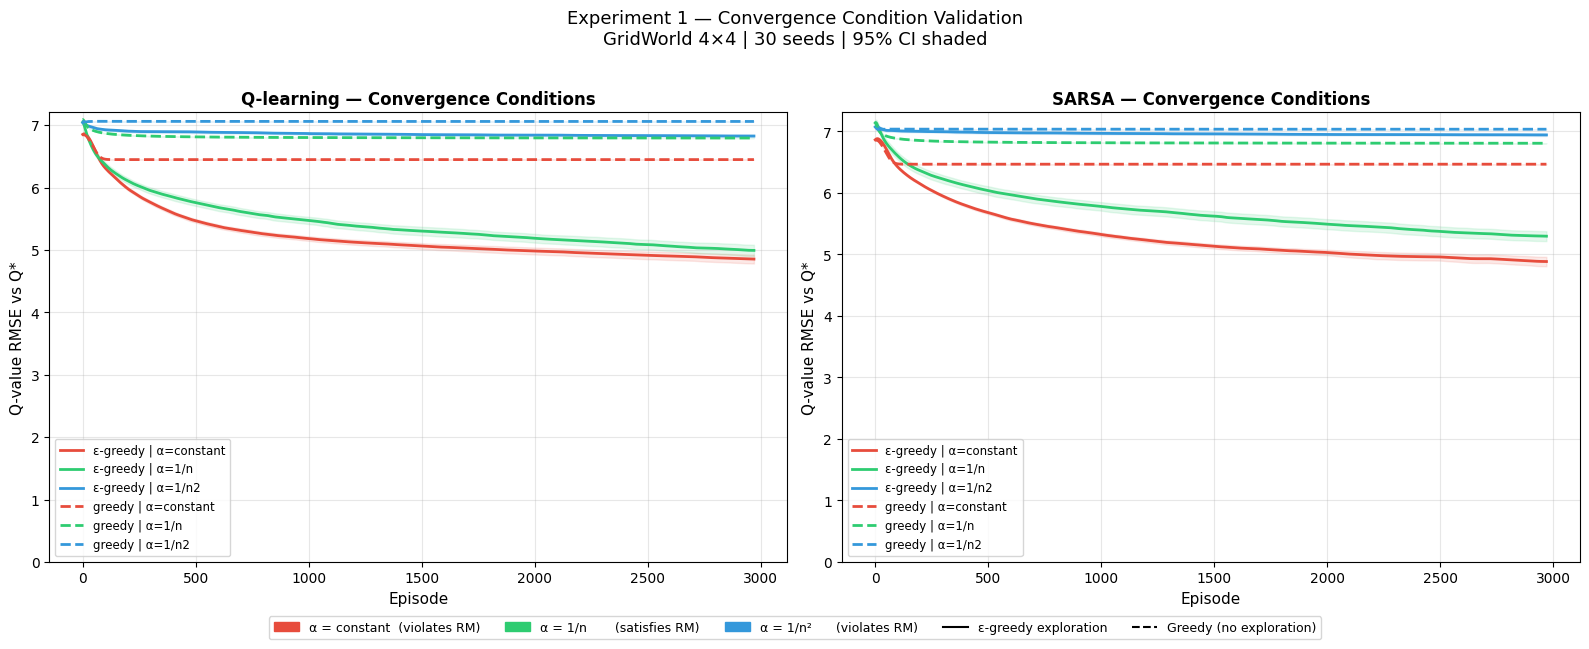

Plot saved: exp1_convergence.png


In [ ]:
COLORS  = {'constant': '#e74c3c', '1/n': '#2ecc71', '1/n2': '#3498db'}
LINES   = {'epsilon_greedy': '-', 'greedy': '--'}
SMOOTH  = 30

def smooth(arr, w):
    return np.convolve(arr, np.ones(w) / w, mode='valid')

def plot_convergence_panel(ax, algo, title):
    episodes = np.arange(N_EPISODES)
    for (a, explore, lr), data in results.items():
        if a != algo:
            continue
        mean = data.mean(axis=0)
        ci   = 1.96 * stats.sem(data, axis=0)

        m_s  = smooth(mean, SMOOTH)
        ci_s = smooth(ci, SMOOTH)
        ep_s = episodes[:len(m_s)]

        label = f"{'ε-greedy' if explore=='epsilon_greedy' else 'greedy'} | α={lr}"
        ax.plot(ep_s, m_s,
                color=COLORS[lr], linestyle=LINES[explore],
                linewidth=2, label=label)
        ax.fill_between(ep_s, m_s - ci_s, m_s + ci_s,
                        color=COLORS[lr], alpha=0.12)

    ax.set_xlabel('Episode', fontsize=11)
    ax.set_ylabel('Q-value RMSE vs Q*', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8.5)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_convergence_panel(axes[0], 'Q-learning', 'Q-learning — Convergence Conditions')
plot_convergence_panel(axes[1], 'SARSA',      'SARSA — Convergence Conditions')


patches = [
    mpatches.Patch(color=COLORS['constant'],  label='α = constant  (violates RM)'),
    mpatches.Patch(color=COLORS['1/n'],       label='α = 1/n       (satisfies RM)'),
    mpatches.Patch(color=COLORS['1/n2'],      label='α = 1/n²      (violates RM)'),
    plt.Line2D([0],[0], color='k', ls='-',  label='ε-greedy exploration'),
    plt.Line2D([0],[0], color='k', ls='--', label='Greedy (no exploration)'),
]
fig.legend(handles=patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Experiment 1 — Convergence Condition Validation\n'
             f'GridWorld 4×4 | {N_SEEDS} seeds | 95% CI shaded',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/exp1_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: exp1_convergence.png")

# 9. Plot 2: Policy Grid Comparison

This cell visualizes the optimal policy (derived from Q\* via Value Iteration) and compares it with policies learned by Q-learning and SARSA under both optimal (ε-greedy + 1/n) and suboptimal (Greedy + 1/n²) conditions.

### How it works:

*   **`draw_policy_grid(ax, Q, title, env)` function**: This helper function takes a Q-table, extracts the greedy policy (by taking `argmax` for each state), and renders it as a grid of arrows. It also highlights the start (S), goal (G), and hole (H) states for easy interpretation.
*   **Policy Generation**: It first generates the optimal Q\* from Value Iteration. Then, it runs Q-learning and SARSA for a single seed (seed=0) under the 'best' conditions (ε-greedy + 1/n) and 'worst' conditions (Greedy + 1/n²). These learned Q-tables are then used to extract their respective policies.

### Some Insights from the plot:

*   **Optimal Conditions (ε-greedy + 1/n)**: Both Q-learning and SARSA, when run with epsilon-greedy exploration and the 1/n learning rate schedule, converge to policies that are visually almost identical to the true optimal policy (Q\*) derived from Value Iteration. This shows that under appropriate conditions, these algorithms can learn the optimal behavior.
*   **Suboptimal Conditions (Greedy + 1/n²)**: When exploration is entirely absent (Greedy) and the learning rate decays too quickly (1/n²), both algorithms fail to learn a meaningful policy. The policy grids for these conditions often show agents getting stuck or taking arbitrary actions, highlighting the disrupting impact of violating convergence conditions. For example, in greedy conditions, the agent often gets stuck moving 'up' from the start state (0), as that's the default action for an uninitialized Q-table, never exploring other paths.
*   **Visual Confirmation**: The policy grids provide a clear, intuitive confirmation of the numerical RMSE results. A low RMSE (as seen in the 1/n ε-greedy cases) translates directly into a visually correct policy, while a high RMSE points to a visibly flawed policy.

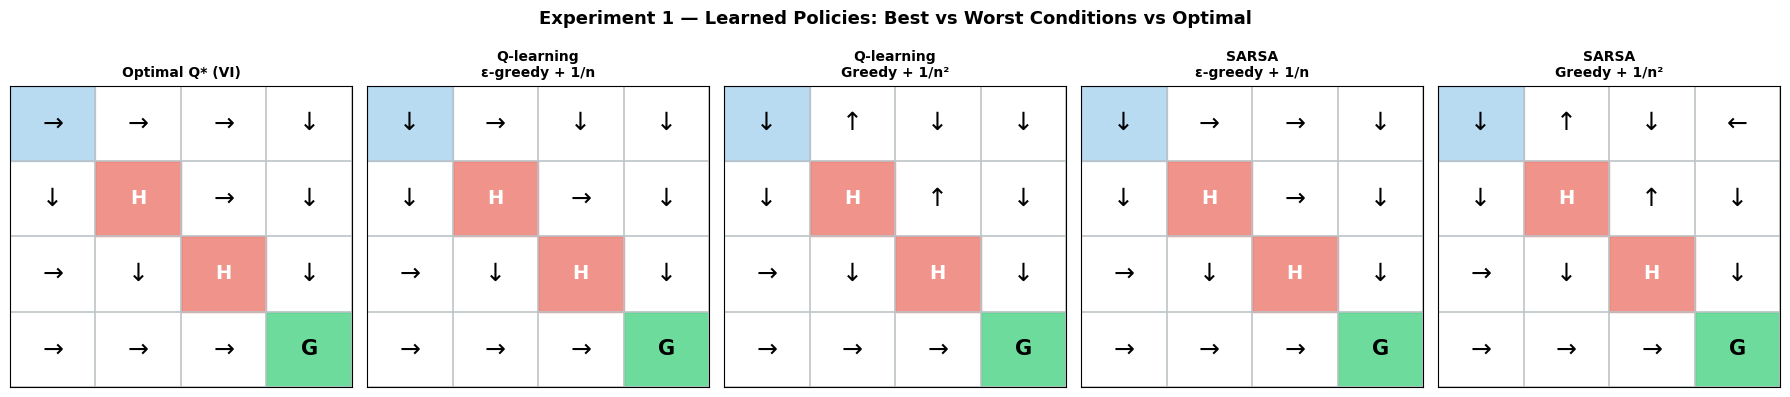

Plot saved: exp1_policies.png


In [ ]:
ARROWS = ['↑', '→', '↓', '←']

def draw_policy_grid(ax, Q, title, env):
    policy = np.argmax(Q, axis=1)
    ax.set_xlim(0, env.size); ax.set_ylim(0, env.size)
    ax.set_xticks(np.arange(env.size + 1))
    ax.set_yticks(np.arange(env.size + 1))
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    ax.grid(True, linewidth=1.2, color='#bdc3c7')
    ax.set_title(title, fontsize=10, fontweight='bold')

    for s in range(env.n_states):
        row, col  = divmod(s, env.size)
        drow      = env.size - 1 - row
        cx, cy    = col + 0.5, drow + 0.5

        if s == env.goal:
            ax.add_patch(plt.Rectangle((col, drow), 1, 1,
                         color='#2ecc71', alpha=0.7, zorder=1))
            ax.text(cx, cy, 'G', ha='center', va='center',
                    fontsize=15, fontweight='bold', zorder=2)
        elif s in env.holes:
            ax.add_patch(plt.Rectangle((col, drow), 1, 1,
                         color='#e74c3c', alpha=0.6, zorder=1))
            ax.text(cx, cy, 'H', ha='center', va='center',
                    fontsize=14, fontweight='bold', color='white', zorder=2)
        elif s == env.start:
            ax.add_patch(plt.Rectangle((col, drow), 1, 1,
                         color='#3498db', alpha=0.35, zorder=1))
            ax.text(cx, cy, ARROWS[policy[s]], ha='center', va='center',
                    fontsize=18, zorder=2)
        else:
            ax.text(cx, cy, ARROWS[policy[s]], ha='center', va='center',
                    fontsize=18, zorder=2)

Q_opt_q, _ = run_qlearning(env, Q_star, '1/n',  'epsilon_greedy', seed=0)
Q_bad_q, _ = run_qlearning(env, Q_star, '1/n2', 'greedy',         seed=0)
Q_opt_s, _ = run_sarsa    (env, Q_star, '1/n',  'epsilon_greedy', seed=0)
Q_bad_s, _ = run_sarsa    (env, Q_star, '1/n2', 'greedy',         seed=0)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
draw_policy_grid(axes[0], Q_star,  'Optimal Q* (VI)',              env)
draw_policy_grid(axes[1], Q_opt_q, 'Q-learning\nε-greedy + 1/n',  env)
draw_policy_grid(axes[2], Q_bad_q, 'Q-learning\nGreedy + 1/n²',   env)
draw_policy_grid(axes[3], Q_opt_s, 'SARSA\nε-greedy + 1/n',       env)
draw_policy_grid(axes[4], Q_bad_s, 'SARSA\nGreedy + 1/n²',        env)

fig.suptitle('Experiment 1 — Learned Policies: Best vs Worst Conditions vs Optimal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/exp1_policies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: exp1_policies.png")

# 10. Summary Table

In [ ]:
# Final RMSE (mean over last 100 episodes, mean over 30 seeds)
print("\n── Experiment 1 Summary: Final RMSE (mean ± std, last 100 eps) ──")
print(f"{'Algorithm':<12} {'Explore':<16} {'LR':<10} {'Final RMSE':>12} {'Std':>8}")
print("─" * 62)
for (algo, explore, lr) in sorted(results.keys()):
    data      = results[(algo, explore, lr)]
    final     = data[:, -100:].mean(axis=1)
    mu, sigma = final.mean(), final.std()
    tag       = 'ε-greedy' if explore == 'epsilon_greedy' else 'greedy'
    print(f"{algo:<12} {tag:<16} {lr:<10} {mu:>12.4f} {sigma:>8.4f}")


── Experiment 1 Summary: Final RMSE (mean ± std, last 100 eps) ──
Algorithm    Explore          LR           Final RMSE      Std
──────────────────────────────────────────────────────────────
Q-learning   ε-greedy         1/n              4.9975   0.2467
Q-learning   ε-greedy         1/n2             6.8256   0.0413
Q-learning   ε-greedy         constant         4.8575   0.1936
Q-learning   greedy           1/n              6.7930   0.0000
Q-learning   greedy           1/n2             7.0587   0.0000
Q-learning   greedy           constant         6.4474   0.0000
SARSA        ε-greedy         1/n              5.3005   0.2220
SARSA        ε-greedy         1/n2             6.9441   0.0494
SARSA        ε-greedy         constant         4.8894   0.2086
SARSA        greedy           1/n              6.8082   0.0000
SARSA        greedy           1/n2             7.0364   0.0000
SARSA        greedy           constant         6.4676   0.0000
